# Task 4

In [5]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

## Configuration

In [18]:
DATA_PATH = "D:/my_project/HW_NLP_01_FatemahDadkhah_Task4/asriran.csv"

TEXT_COLUMN = "clean_text" 
LABEL_COLUMN = "subgroup"    #'service' only has 2 non-topical values, not useful here

MIN_SAMPLES_PER_CLASS = 500  # It leaves out topics that are too rare to learn and cannot be reliably learned.
TEST_SIZE = 0.20
RANDOM_STATE = 42

MODEL_CHOICE = "LinearSVC"   # or "LogisticRegression"

print(f"Text column: {TEXT_COLUMN}")
print(f"Label column: {LABEL_COLUMN}")
print(f"Model: {MODEL_CHOICE}")

Text column: clean_text
Label column: subgroup
Model: LinearSVC


## Preprocessing

### The cleaning has already been done in the CSV file and the clean_text column has already been created in the original file and the same is used here.

In [ ]:
# import re
# import pandas as pd
# from hazm import Normalizer, word_tokenize

# try:
#     from hazm import stopwords_list
# except ImportError:
#     from hazm.utils import stopwords_list

# EMOJI_PATTERN = re.compile(
#     "["
#     "\U0001F600-\U0001F64F"
#     "\U0001F300-\U0001F5FF"
#     "\U0001F680-\U0001F6FF"
#     "\U0001F1E0-\U0001F1FF"
#     "\U00002700-\U000027BF"
#     "\U0001F900-\U0001F9FF"
#     "\U00002600-\U000026FF"
#     "]+",
#     flags=re.UNICODE,
# )

# URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)")
# PUNCTUATION_PATTERN = re.compile(r"[!\"#$%&()*+,./:;<=>?@\[\]^_`{|}~«»–—\-…؟،؛٪]")
# DIGIT_PATTERN = re.compile(r"[0-9\u06F0-\u06F9]+")
# MULTI_SPACE_PATTERN = re.compile(r"\s+")


# def remove_noise_regex(text: str) -> str:
#     if not isinstance(text, str):
#         return ""
#     text = URL_PATTERN.sub(" ", text)
#     text = EMOJI_PATTERN.sub(" ", text)
#     text = DIGIT_PATTERN.sub(" ", text)
#     text = PUNCTUATION_PATTERN.sub(" ", text)
#     text = MULTI_SPACE_PATTERN.sub(" ", text).strip()
#     return text


# ELONGATION_PATTERN = re.compile(r"(.)\1{2,}")


# def fix_elongation(text: str) -> str:
#     return ELONGATION_PATTERN.sub(r"\1", text)


# normalizer = Normalizer()

# persian_stopwords = set(stopwords_list())

# NEGATION_WORDS = {
#     "نه", "نیست", "نمی", "نمیشود", "نمی‌شود", "نبود", "نداشت",
#     "هیچ", "بدون", "نکرد", "نکردم", "نداره", "ندارد", "نداریم",
#     "نکنید", "نمی‌کند", "نمیکند", "نمی‌کنم", "نمیکنم",
# }

# custom_stopwords = persian_stopwords - NEGATION_WORDS


# def remove_stopwords(text: str) -> str:
#     tokens = word_tokenize(text)
#     filtered_tokens = [tok for tok in tokens if tok not in custom_stopwords]
#     return " ".join(filtered_tokens)


# def clean_persian_text(text: str) -> str:
#     if not isinstance(text, str) or text.strip() == "":
#         return ""

#     text = remove_noise_regex(text)
#     text = fix_elongation(text)
#     text = normalizer.normalize(text)
#     text = remove_stopwords(text)

#     return text


# print("Applying clean_persian_text() to the raw body column...")
# df["clean_text"] = df["body"].apply(clean_persian_text)

# print("Preprocessing complete.")
# print(df[["body", "clean_text"]].head(3))

In [19]:
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)

# Drop rows with missing text or label
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)
print("Shape after dropping NaN:", df.shape)

# Remove classes with too few samples to be learned reliably
class_counts = df[LABEL_COLUMN].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
df = df[df[LABEL_COLUMN].isin(valid_classes)].reset_index(drop=True)

print(f"Number of topic classes kept: {df[LABEL_COLUMN].nunique()}")
print("Final shape ready for modeling:", df.shape)
print("\nClass distribution:")
print(df[LABEL_COLUMN].value_counts())

Raw shape: (107390, 8)
Shape after dropping NaN: (93346, 8)
Number of topic classes kept: 13
Final shape ready for modeling: (92130, 8)

Class distribution:
subgroup
اجتماعی                  28509
بین الملل                14486
اقتصادی                  11724
سیاسی                    11157
ورزشی                     5675
فرهنگی/هنری               4825
سیاست خارجی               4056
سلامت                     3226
حوادث                     3150
خواندنی ها و دیدنی ها     1798
عمومی                     1599
علمی                       986
فناوری و IT                939
Name: count, dtype: int64


## Vectorization

### Vectorization with TF-IDF

In [20]:
X_text = df[TEXT_COLUMN]
y = df[LABEL_COLUMN]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  
)

print(f"Train size: {len(X_train_text)}, Test size: {len(X_test_text)}")

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF train matrix shape:", X_train.shape)
print("TF-IDF test matrix shape :", X_test.shape)


Train size: 73704, Test size: 18426
TF-IDF train matrix shape: (73704, 50000)
TF-IDF test matrix shape : (18426, 50000)


## Evaluation

### Model training

### Train the model

In [21]:
if MODEL_CHOICE == "LogisticRegression":
    model = LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",  # explicit multi-class configuration
        solver="lbfgs",
        class_weight="balanced",     # helps with the remaining class imbalance
        random_state=RANDOM_STATE,
    )
else:
    model = LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=5000,
    )

model.fit(X_train, y_train)
print(f"{MODEL_CHOICE} trained successfully on {X_train.shape[0]} samples.")

LinearSVC trained successfully on 73704 samples.


Result for LogisticRegression: LogisticRegression trained successfully on 73704 samples.

In [23]:
y_pred = model.predict(X_test)

report_dict = classification_report(y_test, y_pred, digits=3, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(3)

report_df.loc["accuracy", ["precision", "recall", "support"]] = [
    None, None, report_df.loc["macro avg", "support"]
]

print(report_df)

                       precision  recall  f1-score  support
اجتماعی                    0.800   0.685     0.738   5702.0
اقتصادی                    0.760   0.777     0.768   2345.0
بین الملل                  0.820   0.855     0.837   2897.0
حوادث                      0.616   0.705     0.657    630.0
خواندنی ها و دیدنی ها      0.567   0.669     0.614    360.0
سلامت                      0.605   0.682     0.641    645.0
سیاست خارجی                0.515   0.647     0.573    811.0
سیاسی                      0.702   0.675     0.688   2231.0
علمی                       0.416   0.503     0.455    197.0
عمومی                      0.336   0.362     0.349    320.0
فرهنگی/هنری                0.719   0.829     0.770    965.0
فناوری و IT                0.471   0.527     0.497    188.0
ورزشی                      0.921   0.959     0.940   1135.0
accuracy                     NaN     NaN     0.736  18426.0
macro avg                  0.635   0.683     0.656  18426.0
weighted avg               0.744   0.736

Result from LogisticRegression :
| class                 | precision | recall | f1-score | support |
| --------------------- | --------- | ------ | -------- | ------- |
| اجتماعی               | 0.851     | 0.550  | 0.668    | 5702    |
| اقتصادی               | 0.758     | 0.780  | 0.769    | 2345    |
| بین الملل             | 0.855     | 0.808  | 0.831    | 2897    |
| حوادث                 | 0.509     | 0.829  | 0.631    | 630     |
| خواندنی ها و دیدنی ها | 0.524     | 0.717  | 0.606    | 360     |
| سلامت                 | 0.498     | 0.764  | 0.603    | 645     |
| سیاست خارجی           | 0.489     | 0.768  | 0.597    | 811     |
| سیاسی                 | 0.707     | 0.671  | 0.688    | 2231    |
| علمی                  | 0.331     | 0.660  | 0.441    | 197     |
| عمومی                 | 0.236     | 0.450  | 0.310    | 320     |
| فرهنگی/هنری           | 0.685     | 0.861  | 0.763    | 965     |
| فناوری و IT           | 0.390     | 0.638  | 0.484    | 188     |
| ورزشی                 | 0.929     | 0.957  | 0.943    | 1135    |
| accuracy              | —         | —      | 0.706    | 18426   |
| macro avg             | 0.597     | 0.727  | 0.641    | 18426   |
| weighted avg          | 0.751     | 0.706  | 0.712    | 18426   |

In [25]:
from sklearn.metrics import accuracy_score
print(f"\nOverall Accuracy on the 20% Test Set: {accuracy_score(y_test, y_pred):.3f}")


Overall Accuracy on the 20% Test Set: 0.736


### Result : LinearSVC is the better model it outperforms LogisticRegression in all three overall metrics: Accuracy 73.6% vs. 70.6%, and Weighted F1 0.738 vs. 0.712. It also has a better F1 score than LogisticRegression in 9 out of 13 topics.
### Key difference: LogisticRegression has a serious weakness on the large “social” class (Recall is only 0.550, meaning it misclassifies half of the social news), while LinearSVC shows better balance on the same class (Recall 0.685).
#### Common weakness of both models: "General" (F1 around 0.31-0.35) and "Scientific" (F1 around 0.44-0.45) topics have the weakest performance in both models.

## Confusion Matrix

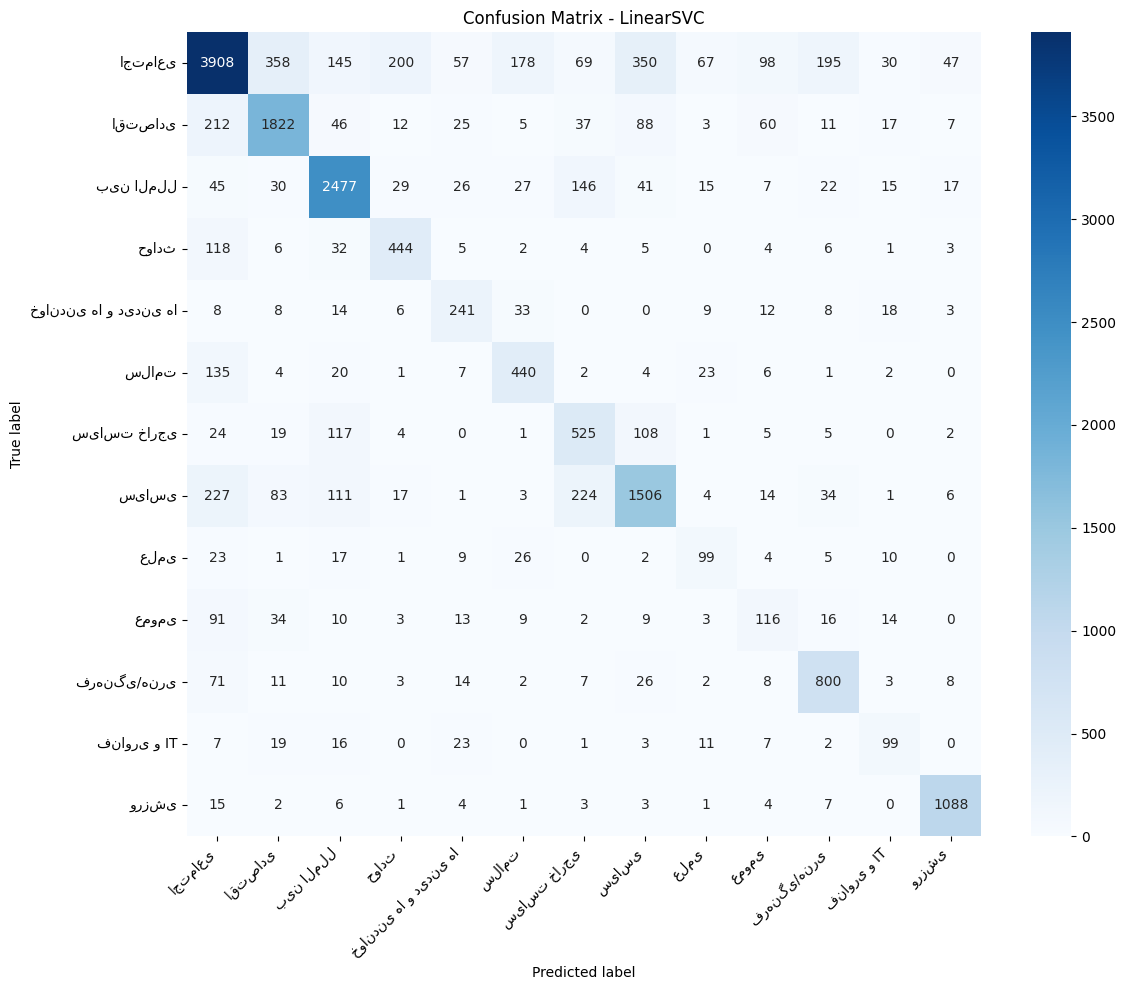

Confusion matrix saved to confusion_matrix.png


In [24]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels_sorted, yticklabels=labels_sorted
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix - {MODEL_CHOICE}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("Confusion matrix saved to confusion_matrix.png")

## سوال تحلیلی: مدل شما کدام دو موضوع را بیشتر با هم اشتباه گرفته است؟ (برای مثال، آیا «اقتصاد» را با «سیاست» اشتباه گرفته است؟) دلیل احتمالی این اشتباه را در دو سطر بنویسید.
> اجتماعی و سیاسی (۵۷۷ مثال نادرست)، و بلافاصله پس از آن اجتماعی و اقتصادی (۵۷۰ مثال نادرست).
>> اجتماعی یک مقوله کلی است که اخبار سیاسی و اقتصادی اغلب با آن همپوشانی واژگانی زیادی دارند، بنابراین مدل TF-IDF نمی تواند مرز مشخصی ترسیم کند.به همین ترتیب، سیاست و سیاست خارجی اغلب به دلیل نام ها و اصطلاحات رایج (کشورها، مقامات) با هم اشتباه گرفته می شوند.